In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import warnings
warnings.simplefilter(action="ignore")

In [2]:
df = pd.read_excel('Telco_customer_churn.xlsx')  # update path if needed

print("Original shape:", df.shape)

Original shape: (7043, 33)


In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.tail()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.424926,-117.184503,Male,...,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No,0,38,5097,NaN


In [5]:
df.isnull()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7039,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7040,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [6]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [8]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [9]:
def check_data(dataframe, head=5):

    print(20*"-" + "Information".center(20) + 20*"-")
    print(dataframe.info())
    print(20*"-" + "Data Shape".center(20) + 20*"-")
    print(dataframe.shape)
    print("\n" + 20*"-" + "The First 5 Data".center(20) + 20*"-")
    print(dataframe.head())
    print("\n" + 20 * "-" + "The Last 5 Data".center(20) + 20 * "-")
    print(dataframe.tail())
    print("\n" + 20 * "-" + "Missing Values".center(20) + 20 * "-")
    print(dataframe.isnull().sum())
    print("\n" + 40 * "-" + "Describe the Data".center(40) + 40 * "-")
    print(dataframe.describe([0.01, 0.05, 0.10, 0.50, 0.75, 0.90, 0.95, 0.99]).T)


check_data(df)

--------------------    Information     --------------------
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     704

## EDA

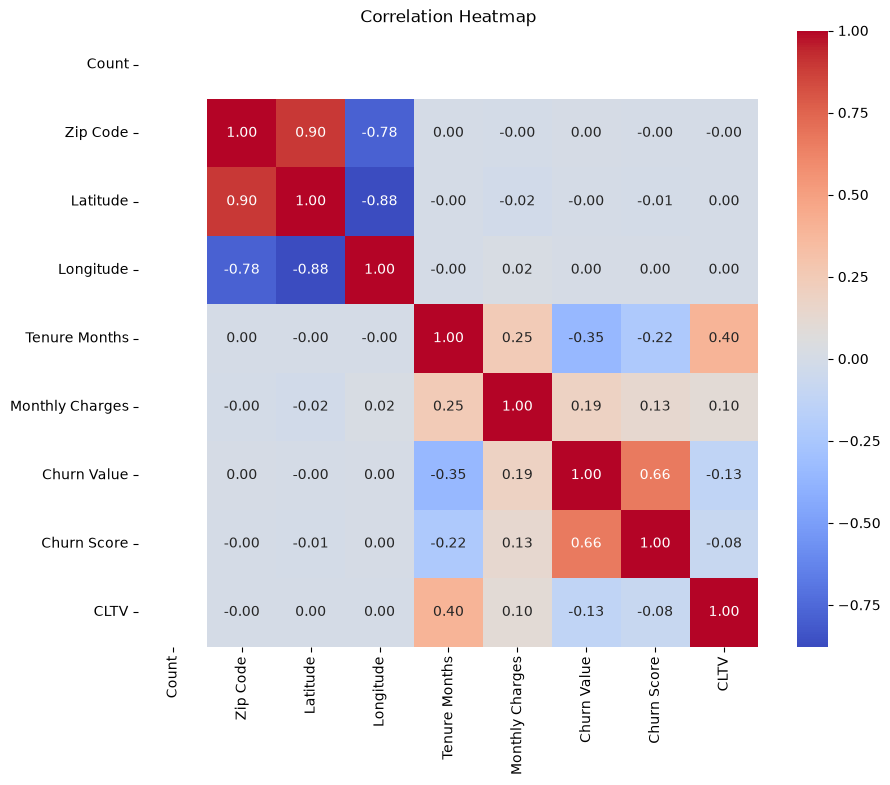

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

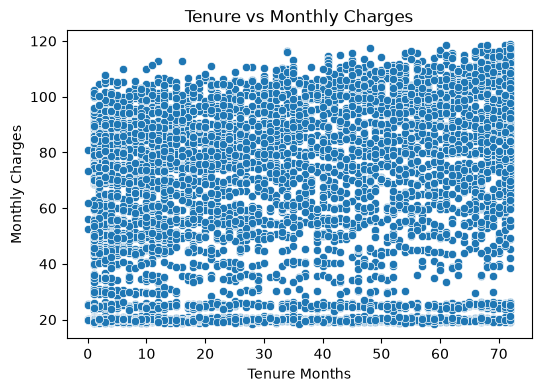

In [14]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Tenure Months', y='Monthly Charges')
plt.title("Tenure vs Monthly Charges")
plt.show()

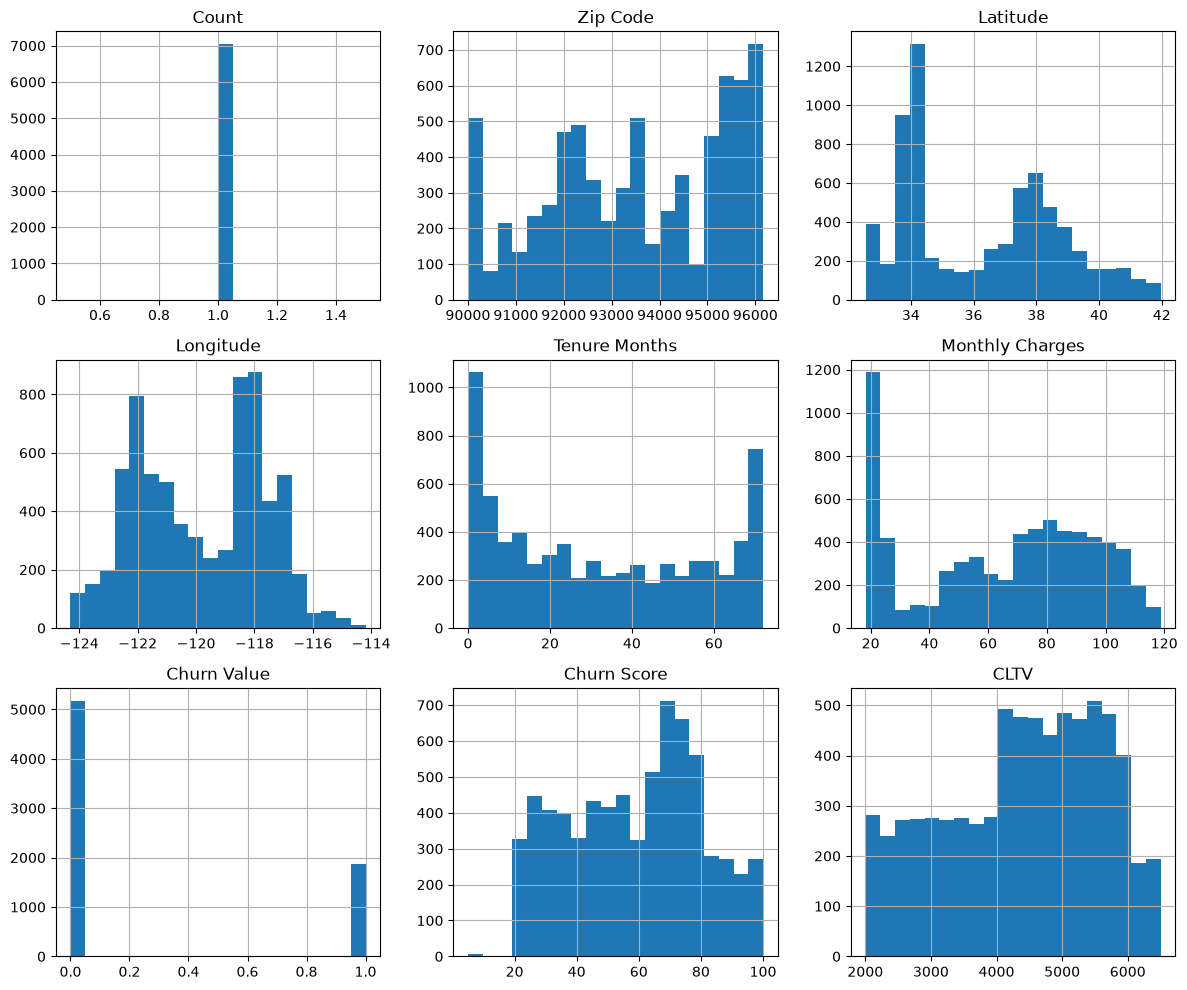

In [15]:
df.select_dtypes(include=np.number).hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

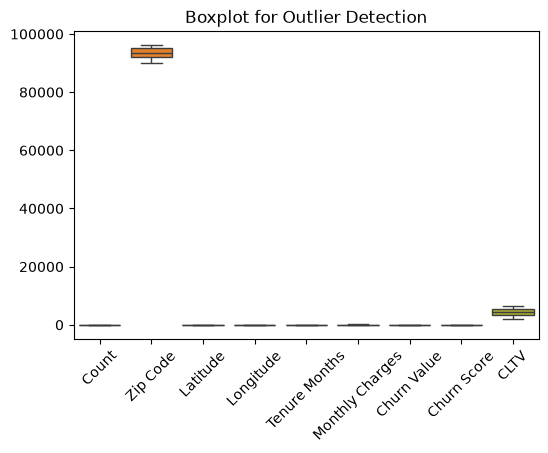

In [16]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection")
plt.show()

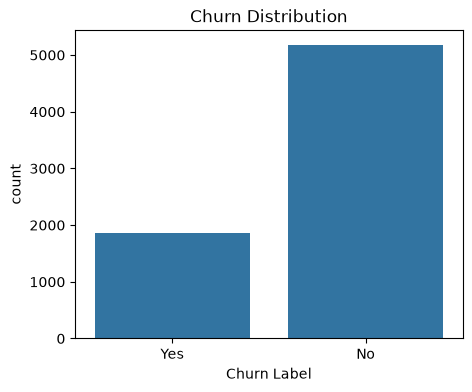

In [17]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Churn Label')
plt.title("Churn Distribution")
plt.show()

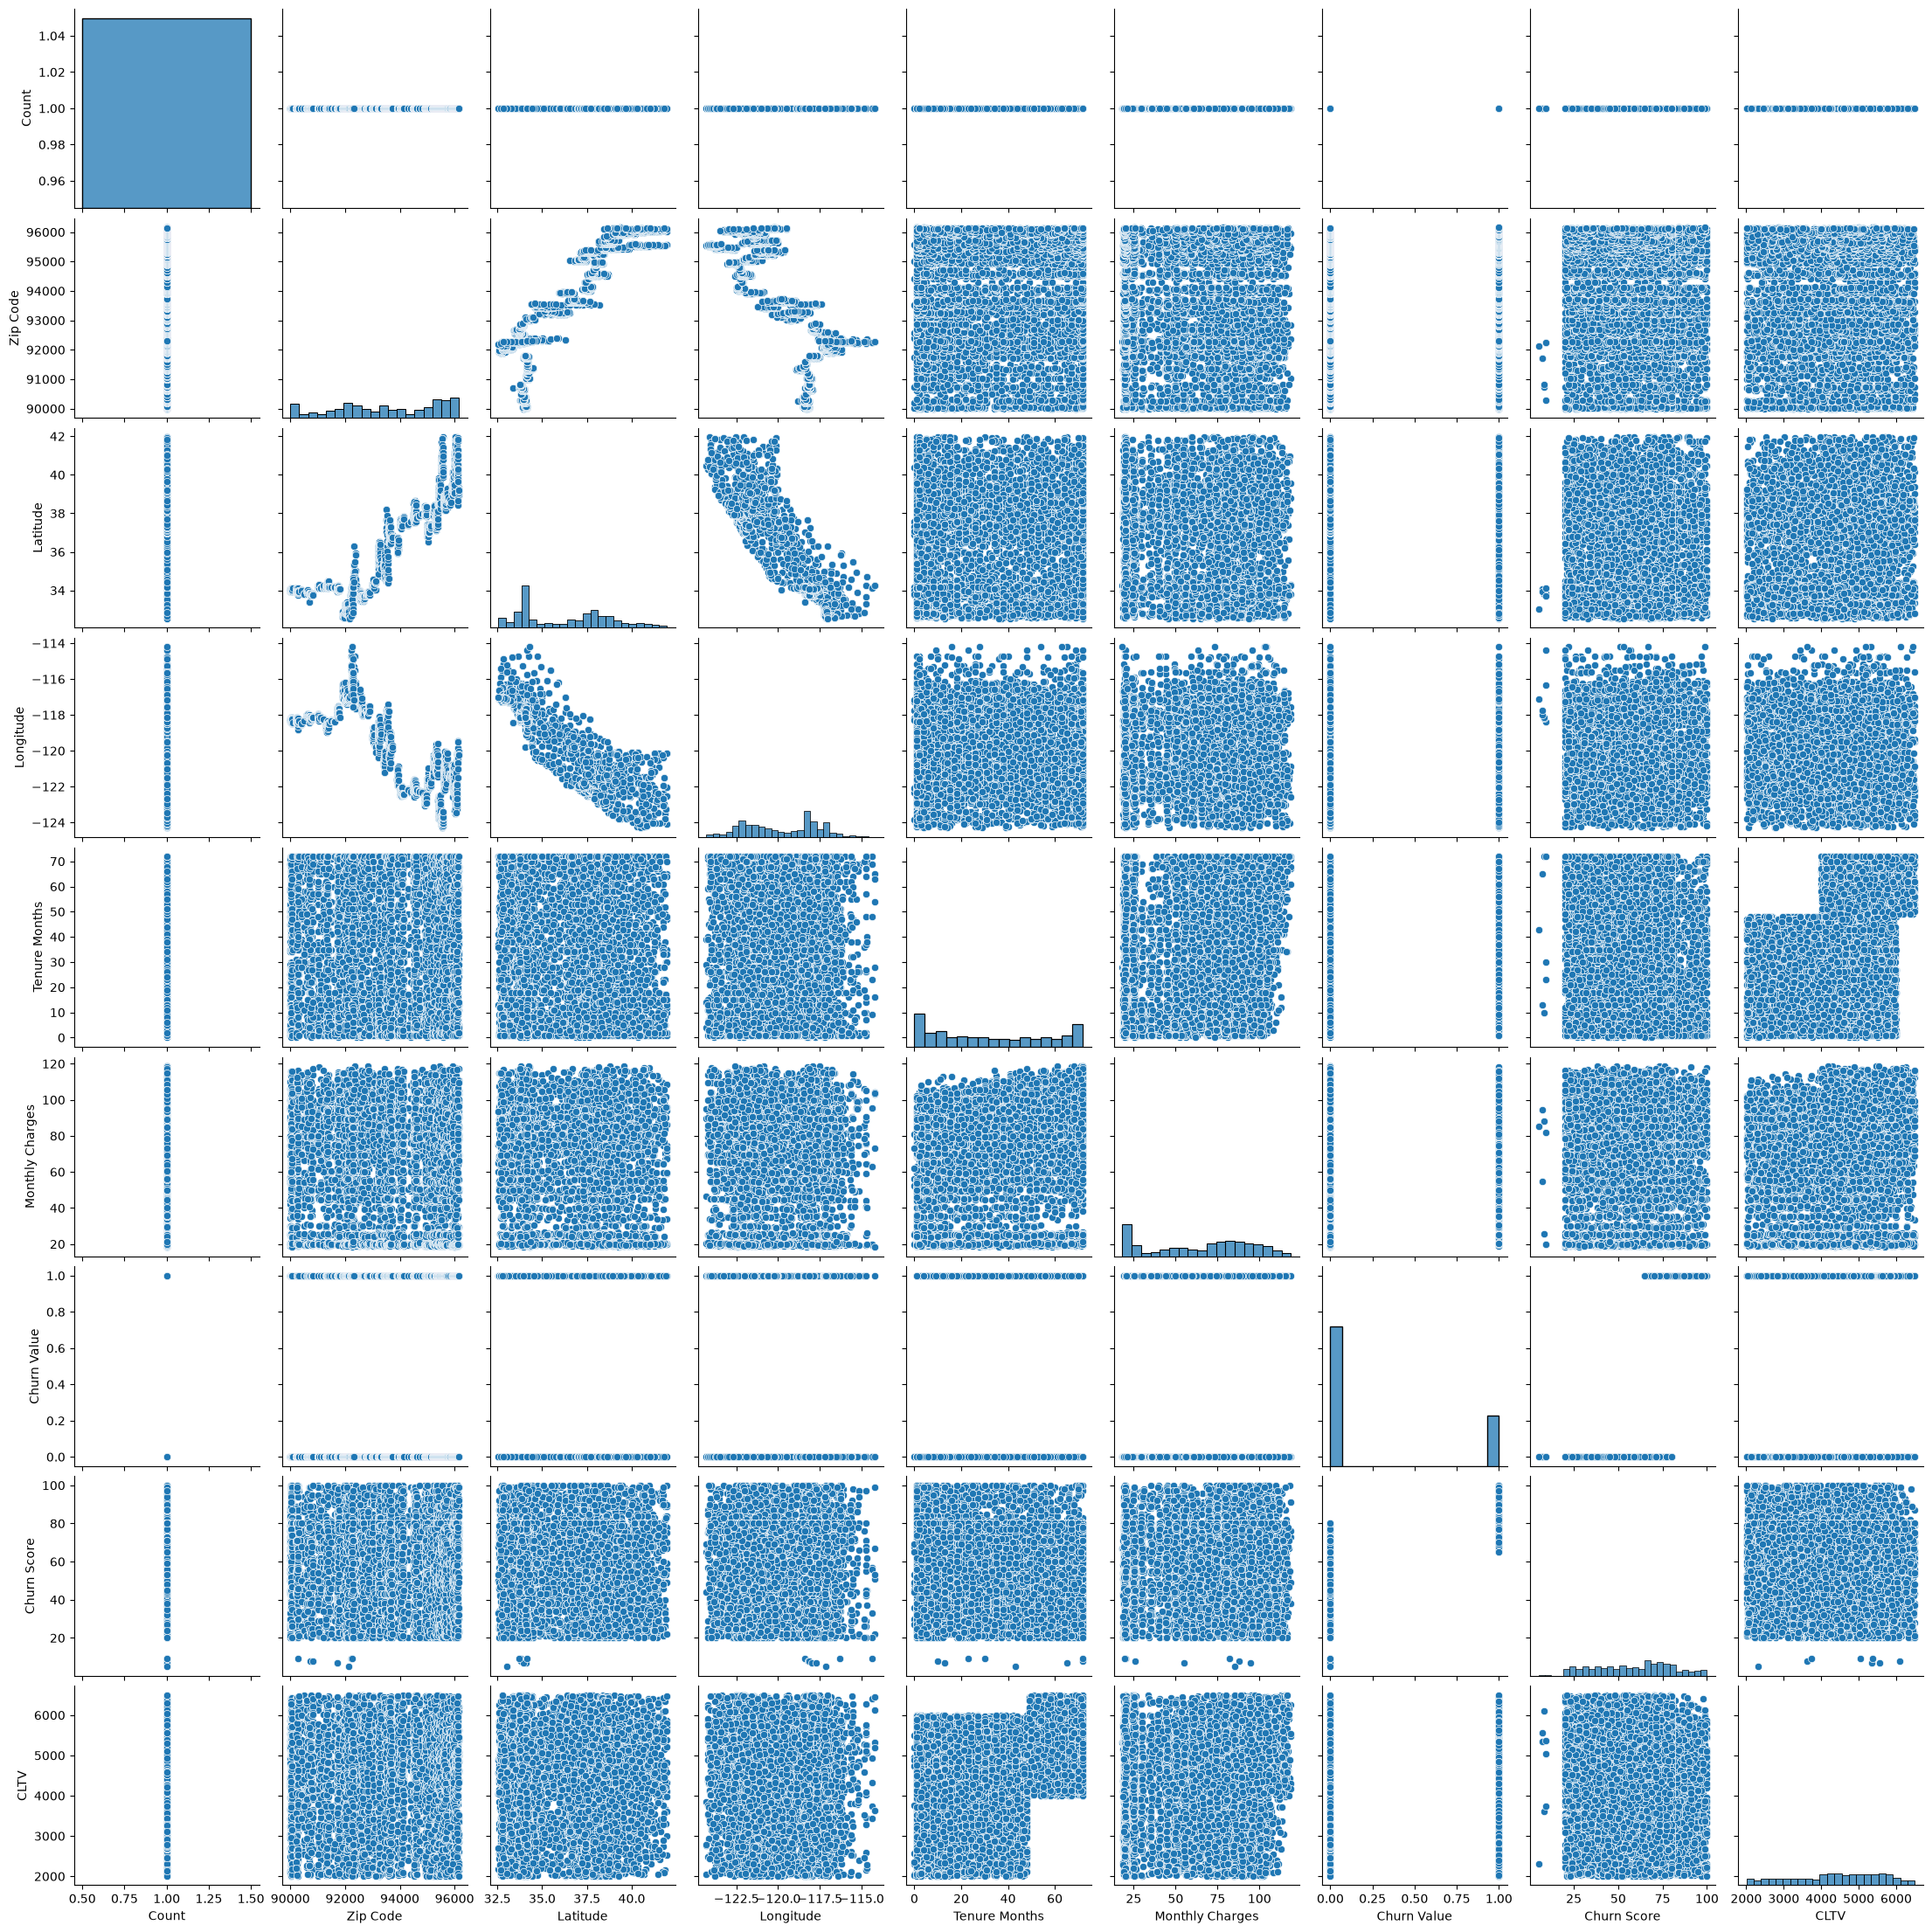

In [18]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.show()

Text(0.5, 1.0, 'Monthly Charges by Contract Type and Churn')

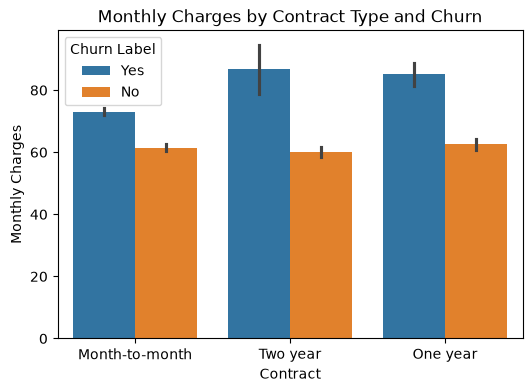

In [19]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Contract', y='Monthly Charges', hue='Churn Label')
plt.title("Monthly Charges by Contract Type and Churn")

## PREPROCESSING

In [20]:
df = df.drop(columns=['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
                       'Lat Long', 'Latitude', 'Longitude', 'Churn Label',
                       'Churn Score', 'Churn Reason'])

In [21]:
from scipy.stats.mstats import winsorize

df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(df['Total Charges'].median())

num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

for col in num_cols:
    df[col] = winsorize(df[col], limits=[0.05, 0.05])

In [22]:
cat_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [23]:
from imblearn.over_sampling import SMOTE

X = df.drop(columns=['Churn Value'])
y = df['Churn Value']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [24]:
print("Before SMOTE:\n", y.value_counts())
print("\nAfter SMOTE:\n", y_resampled.value_counts())

Before SMOTE:
 Churn Value
0    5174
1    1869
Name: count, dtype: int64

After SMOTE:
 Churn Value
1    5174
0    5174
Name: count, dtype: int64


In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_resampled, test_size=0.2, random_state=42)

In [27]:
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 8278
Testing set size: 2070


## MODELLING

In [28]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8231884057971014


In [29]:
from sklearn.svm import SVC

svm_linear_model = SVC(kernel='linear', probability=True, random_state=42)
svm_linear_model.fit(X_train, y_train)
y_pred_svm_linear = svm_linear_model.predict(X_test)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm_linear))

Linear SVM Accuracy: 0.8188405797101449


In [30]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.808695652173913


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8705314009661835


In [32]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.8483091787439614


In [34]:
cv_results = cross_validate(rf_model, X_scaled, y_resampled, cv=5,
                             scoring=['accuracy', 'precision', 'recall', 'f1'])

print("CV Accuracy:", cv_results['test_accuracy'].mean())
print("CV Precision:", cv_results['test_precision'].mean())
print("CV Recall:", cv_results['test_recall'].mean())
print("CV F1 Score:", cv_results['test_f1'].mean())

CV Accuracy: 0.8458769084927489
CV Precision: 0.8476258431585786
CV Recall: 0.842122239976079
CV F1 Score: 0.8350252334561727


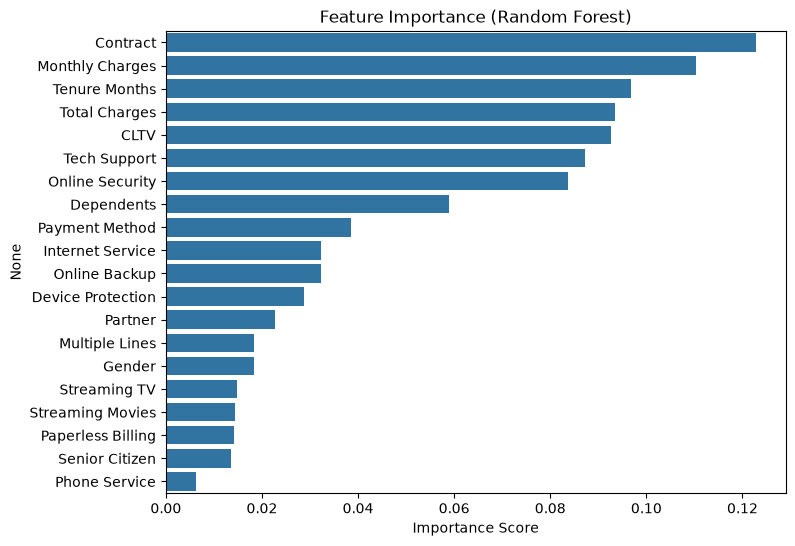

In [35]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

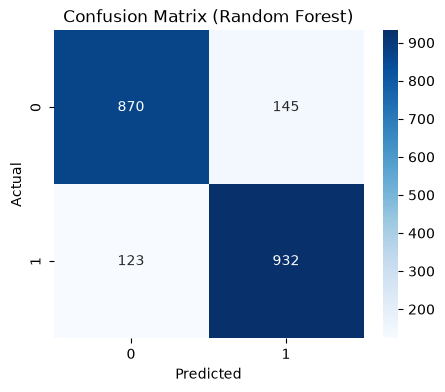

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

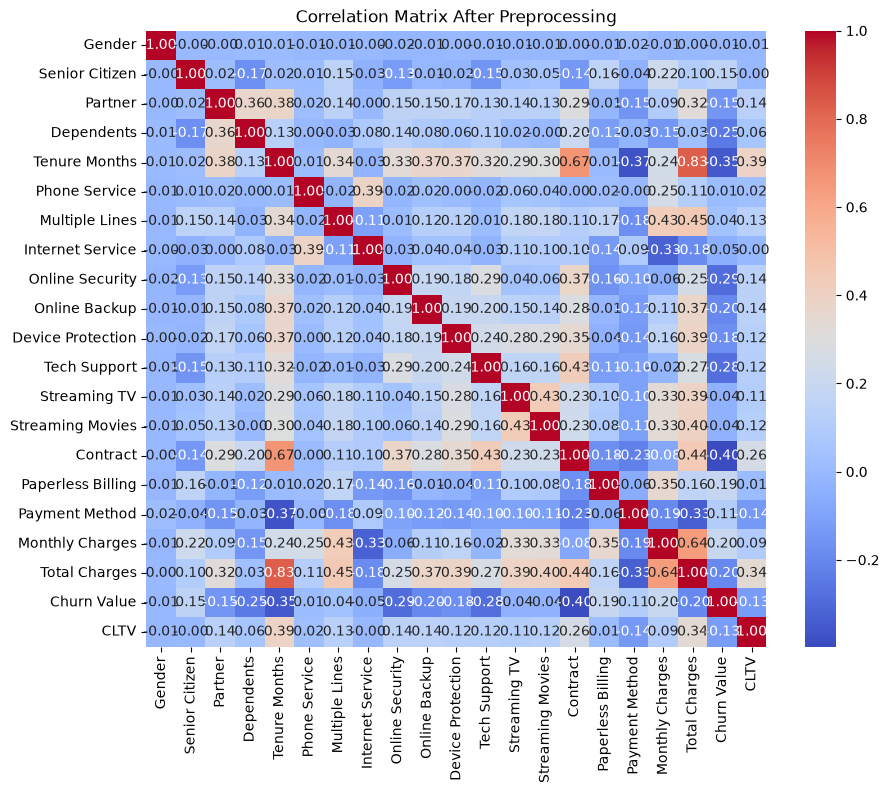

In [37]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix After Preprocessing")
plt.show()

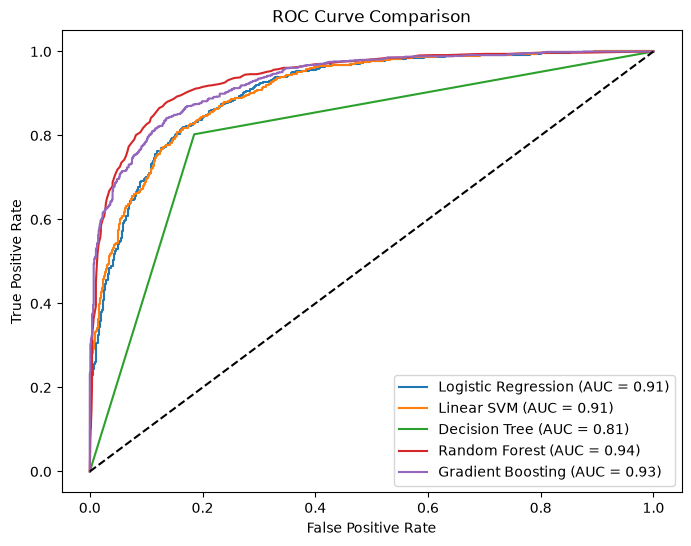

In [38]:
from sklearn.metrics import roc_curve

model_probs = {
    'Logistic Regression': log_model.predict_proba(X_test)[:, 1],
    'Linear SVM': svm_linear_model.predict_proba(X_test)[:, 1],
    'Decision Tree': dt_model.predict_proba(X_test)[:, 1],
    'Random Forest': rf_model.predict_proba(X_test)[:, 1],
    'Gradient Boosting': gb_model.predict_proba(X_test)[:, 1]
}

plt.figure(figsize=(8, 6))
for name, probs in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

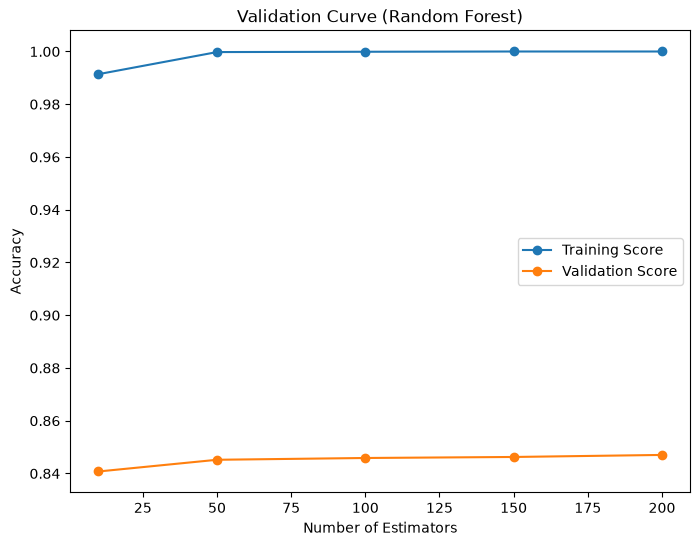

In [39]:
from sklearn.model_selection import validation_curve

param_range = [10, 50, 100, 150, 200]

train_scores, test_scores = validation_curve(
    RandomForestClassifier(random_state=42), X_scaled, y_resampled,
    param_name="n_estimators", param_range=param_range,
    cv=5, scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(param_range, train_mean, label="Training Score", marker='o')
plt.plot(param_range, test_mean, label="Validation Score", marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("Validation Curve (Random Forest)")
plt.legend()
plt.show()

## ERROR ANALYSIS

In [40]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)
X_test_df['Actual'] = y_test.values
X_test_df['Predicted'] = y_pred_rf

errors = X_test_df[X_test_df['Actual'] != X_test_df['Predicted']]
print("Number of misclassified samples:", errors.shape[0])
errors.head()

Number of misclassified samples: 268


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV,Actual,Predicted
2,1.166593,-0.388660,1.287674,-0.433973,0.219622,0.361158,-0.963151,0.292801,-0.750443,-0.881072,...,1.239351,1.240230,-0.641267,-1.206734,0.458704,0.836133,0.445752,-0.883562,0,1
9,-0.857197,-0.388660,-0.776594,-0.433973,-0.406532,0.361158,1.209186,0.292801,-0.750443,-0.881072,...,-1.026316,-1.033873,-0.641267,0.828683,0.458704,0.223086,-0.321373,0.615694,0,1
15,-0.857197,-0.388660,1.287674,-0.433973,1.096238,0.361158,1.209186,-1.170920,-0.750443,-0.881072,...,1.239351,1.240230,0.670940,0.828683,-0.551441,0.079683,0.802034,0.238507,1,0
32,1.166593,2.572942,1.287674,-0.433973,1.263212,-2.768875,0.123018,-1.170920,-0.750443,1.461510,...,-1.026316,1.240230,-0.641267,0.828683,0.458704,-0.811206,0.297451,0.970441,1,0
46,1.166593,-0.388660,1.287674,-0.433973,0.804033,0.361158,1.209186,0.292801,1.732160,-0.881072,...,1.239351,1.240230,0.670940,0.828683,-0.551441,1.415121,1.541595,-0.842132,1,0


In [41]:
false_positives = X_test_df[(X_test_df['Actual'] == 0) & (X_test_df['Predicted'] == 1)]
false_negatives = X_test_df[(X_test_df['Actual'] == 1) & (X_test_df['Predicted'] == 0)]

print("False Positives:", false_positives.shape[0])
print("False Negatives:", false_negatives.shape[0])

False Positives: 145
False Negatives: 123


In [42]:
correct = X_test_df[X_test_df['Actual'] == X_test_df['Predicted']]

comparison = pd.DataFrame({
    'Correct_Mean': correct[X.columns].mean(),
    'Error_Mean': errors[X.columns].mean()
})

comparison['Difference'] = comparison['Correct_Mean'] - comparison['Error_Mean']
comparison.sort_values('Difference', ascending=False)

,Correct_Mean,Error_Mean,Difference
Contract,0.052703,-0.381764,0.434466
Tenure Months,0.001337,-0.232237,0.233574
Dependents,0.055328,-0.168321,0.223649
Tech Support,0.030660,-0.170382,0.201042
Total Charges,-0.016906,-0.118230,0.101324
Device Protection,-0.022457,-0.123588,0.101131
CLTV,0.001503,-0.092584,0.094087
Internet Service,0.011753,-0.078591,0.090344
Online Security,-0.013377,-0.055685,0.042308
Streaming Movies,-0.026806,-0.036832,0.010025


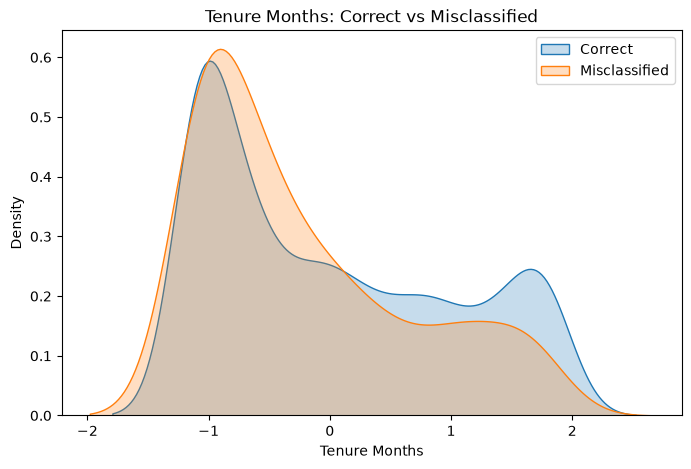

In [43]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=correct, x='Tenure Months', label='Correct', fill=True)
sns.kdeplot(data=errors, x='Tenure Months', label='Misclassified', fill=True)
plt.title("Tenure Months: Correct vs Misclassified")
plt.legend()
plt.show()

In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87      1015
           1       0.87      0.88      0.87      1055

    accuracy                           0.87      2070
   macro avg       0.87      0.87      0.87      2070
weighted avg       0.87      0.87      0.87      2070

